In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [2]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 614
Testing Samples: 154


In [5]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

print("Decision Tree Metrics")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC AUC  :", dt_auc)

Decision Tree Metrics
Accuracy : 0.7272727272727273
Precision: 0.6428571428571429
Recall   : 0.5
F1 Score : 0.5625
ROC AUC  : 0.6749999999999999


In [6]:
results = []
for n in [100, 200, 500]:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    prob = rf.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    results.append([
        n,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

rf_results = pd.DataFrame(
    results,
    columns=[
        "n_estimators",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

rf_results

,n_estimators,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,100,0.759740,0.680851,0.592593,0.633663,0.811759
1,200,0.746753,0.653061,0.592593,0.621359,0.813333
2,500,0.733766,0.627451,0.592593,0.609524,0.813796


In [7]:
best_rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)

rf_prob = best_rf.predict_proba(X_test)[:, 1]

In [8]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

Glucose                     0.267898
BMI                         0.161441
Age                         0.131836
DiabetesPedigreeFunction    0.124177
BloodPressure               0.085433
Pregnancies                 0.083764
Insulin                     0.074293
SkinThickness               0.071160
dtype: float64

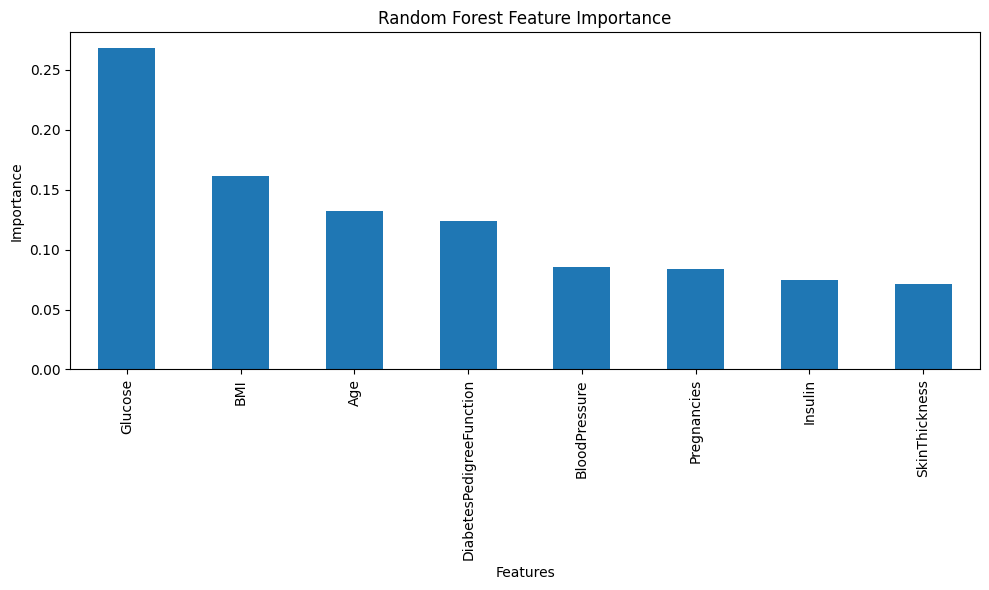

In [9]:
plt.figure(figsize=(10,6))

feature_importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()

plt.savefig("../results/rf_feature_importance.png")

plt.show()

In [10]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1,
        dt_auc
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.727273,0.733766
1,Precision,0.642857,0.627451
2,Recall,0.500000,0.592593
3,F1 Score,0.562500,0.609524
4,ROC AUC,0.675000,0.813796


In [11]:
comparison.to_csv(
    "../results/dt_vs_rf_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.
